# A3 · 醫學影像的不確定性與 OOD 偵測(二):驗證、決策與成本

接續 `01_uncertainty_and_ood.ipynb`。這本處理三件事:

1. **驗證熵分解是否真的分離兩種不確定性** —— 本專案的方法論核心
2. 校準與 OOD 偵測是**不同**的事
3. 把不確定性接上決策層(risk–coverage,通關標準 3)與計算成本的取捨

In [1]:
import sys, os, json, warnings; warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('../src'))
import numpy as np, pandas as pd
from IPython.display import Image, display
FIG = os.path.abspath('../figures')
RES = json.load(open(os.path.join(FIG, 'results.json')))
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 60)
cfg = RES['config']
print(f"results.json from a {RES['_meta']['runtime_sec']:.0f}s run on {RES['_meta']['gpu']}")
print(f"config: M={cfg['M_ensemble']} ensemble members, T={cfg['T_mc']} MC samples, "
      f"{cfg['epochs']} epochs, PathMNIST subsampled to {cfg['path_subsample']}")


results.json from a 180s run on NVIDIA GeForce RTX 5070 Ti
config: M=5 ensemble members, T=50 MC samples, 30 epochs, PathMNIST subsampled to 20000


## 1. 分解名符其實嗎?

大部分作品算了 aleatoric / epistemic 就結束,從不檢查分解是否真的在分離兩種不確定性。
但那個公式是一個**恆等式**——它一定成立;問題是兩邊的量是否真的對應到宣稱的語意。

受控對照:

| 操作 | 做了什麼 | 理論預期 |
|---|---|---|
| 加高斯噪聲 | 影像本身變模糊、類別界線變不清 | 主要抬升 **aleatoric** |
| 換分佈(真 OOD) | 模型缺乏知識 | 主要抬升 **epistemic** |

用**比值**而非差值衡量選擇性,因為兩個分量的絕對尺度不同
(epistemic 通常小一個量級),直接比 $\Delta$ 大小會系統性偏向 aleatoric:

$$\text{noise selectivity} = \frac{\Delta\text{aleatoric}}{|\Delta\text{epistemic}|},\qquad
\text{shift selectivity} = \frac{\Delta\text{epistemic}}{|\Delta\text{aleatoric}|}$$

兩者都應該 $> 1$。

In [2]:
dv = RES['decomposition_validation']
rows = []
for m, s in dv['selectivity'].items():
    if s['degenerate']:
        print(f"{m}: 單一模型的 epistemic 恆為 0（T=1），選擇性無定義 → 跳過")
        continue
    rows.append({'方法': m,
                 '噪聲 Δale': s['noise_d_ale'], '噪聲 Δepi': s['noise_d_epi'],
                 '噪聲選擇性': s['noise_selectivity'],
                 '換分佈 Δale': s['shift_d_ale'], '換分佈 Δepi': s['shift_d_epi'],
                 '換分佈選擇性': s['shift_selectivity']})
display(pd.DataFrame(rows).round(4))
print()
print('噪聲選擇性 > 1  → 加噪聲確實主要抬升 aleatoric（如預期）')
print('換分佈選擇性 > 1 → 換分佈確實主要抬升 epistemic（如預期）')

single: 單一模型的 epistemic 恆為 0（T=1），選擇性無定義 → 跳過


,方法,噪聲 Δale,噪聲 Δepi,噪聲選擇性,換分佈 Δale,換分佈 Δepi,換分佈選擇性
0,mcdrop,0.0233,0.0066,3.5020,0.1553,0.0460,0.2960
1,ensemble,0.0348,0.0290,1.1976,0.1539,0.1163,0.7553



噪聲選擇性 > 1  → 加噪聲確實主要抬升 aleatoric（如預期）
換分佈選擇性 > 1 → 換分佈確實主要抬升 epistemic（如預期）


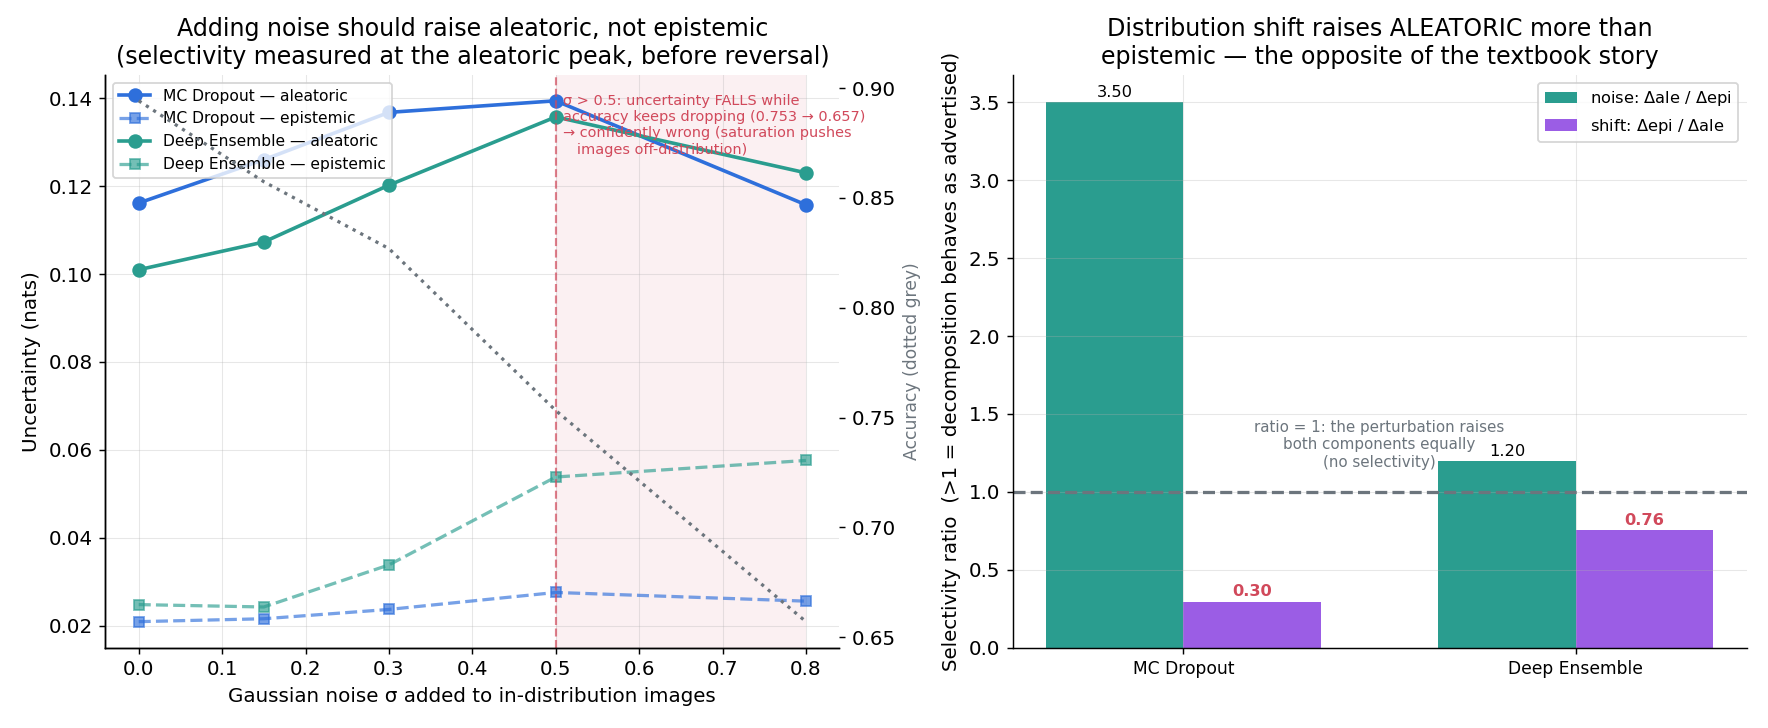

In [3]:
display(Image(os.path.join(FIG, '03_decomposition_validation.png')))

### 結果:分解只在一半的情境下名符其實

- **加噪聲 → aleatoric**:MC Dropout 的選擇性明顯 > 1,如預期。
  同時準確率隨噪聲下降(圖左的灰色虛線),證明噪聲確實在破壞資訊,
  所以 aleatoric 上升是有意義的,不是數值假影。
- **換分佈 → epistemic**:**選擇性 < 1,方向與教科書相反。**
  OOD 影像主要抬升的是 **aleatoric**,不是 epistemic。

換句話說,模型把「我沒見過這種東西」錯誤地記錄成「這張圖本身很模糊」。
這直接解釋了第一本 notebook 的結果:**用 epistemic 當 OOD 分數效果不如宣稱,
因為 OOD 訊號大部分沒有進到 epistemic 這個分量裡。**

這與近年的批評文獻一致。分解在數學上永遠成立,但它的**語意標籤**
在深度學習裡並不可靠 —— 而這件事只有做了受控實驗才會發現。

## 2. 校準與 OOD 偵測是不同的事

這兩者常被混為一談。一個模型可以在 in-distribution 上校準得很好,
卻完全偵測不到 OOD(本專案的 FashionMNIST 組正是如此)。分開報告才看得出來。

In [4]:
rows = []
for m, v in RES['calibration'].items():
    rows.append({'方法': m, 'ECE': v['ece'], '準確率': v['accuracy'],
                 '平均信心': v['mean_conf'],
                 '過度自信?': '是' if v['mean_conf'] > v['accuracy'] else '否'})
display(pd.DataFrame(rows).round(4))
print()
print('track 1 (Pneumonia) 準確率:', {k: round(v,4) for k,v in RES['accuracy']['track1'].items()})
print('track 2 (PathMNIST) 準確率:', {k: round(v,4) for k,v in RES['accuracy']['track2'].items()})

,方法,ECE,準確率,平均信心,過度自信?
0,single,0.0734,0.8990,0.9582,是
1,mcdrop,0.0626,0.8942,0.9435,是
2,ensemble,0.0790,0.8654,0.9444,是



track 1 (Pneumonia) 準確率: {'single': 0.899, 'mcdrop': 0.8942, 'ensemble': 0.8654}
track 2 (PathMNIST) 準確率: {'single': 0.8388, 'mcdrop': 0.8402, 'ensemble': 0.882}


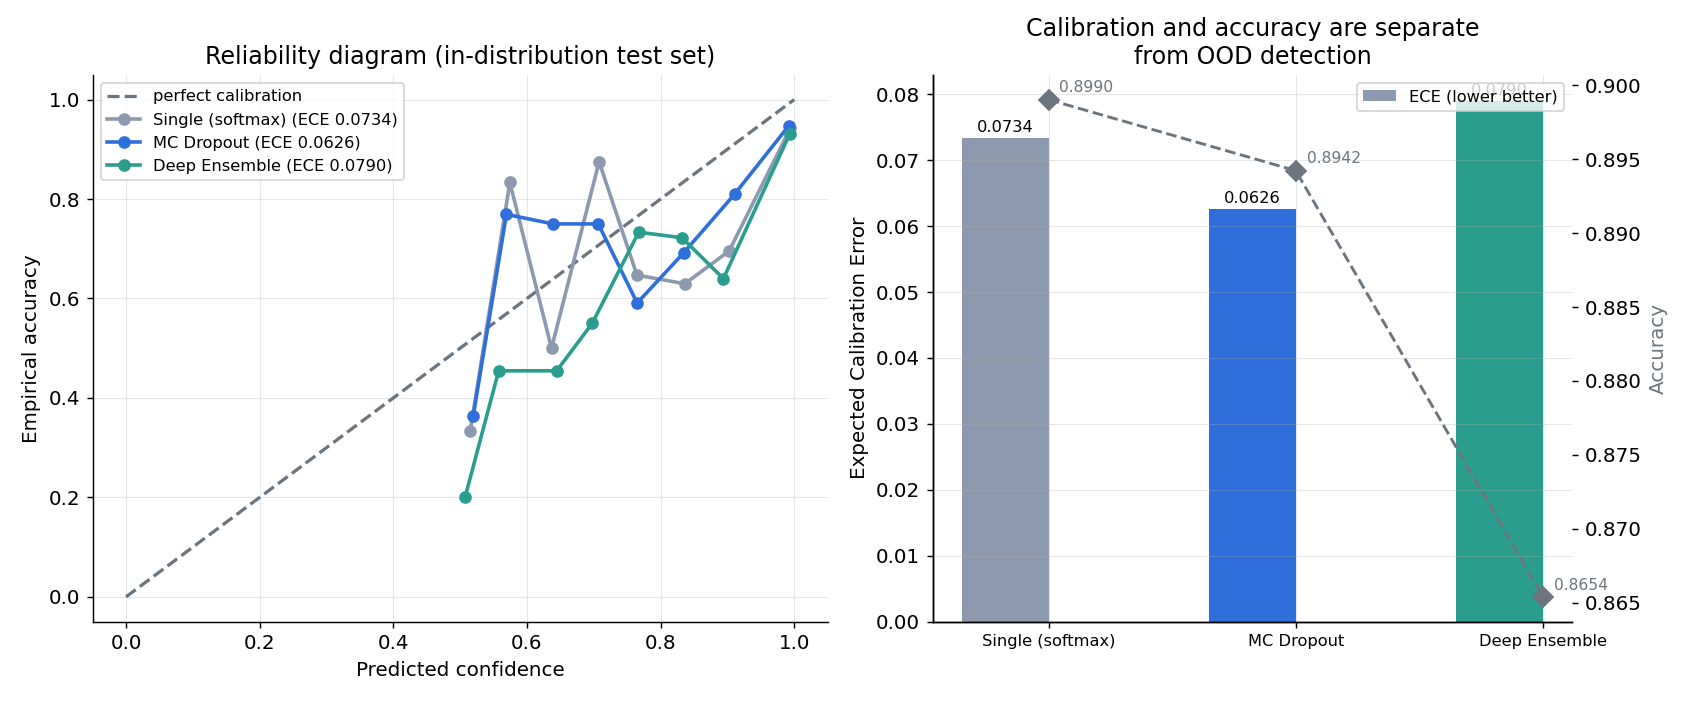

In [5]:
display(Image(os.path.join(FIG, '06_calibration.png')))

## 3. 通關標準 3:接上決策層 —— risk–coverage

這是把不確定性變成**可執行的決策**:不確定性超過門檻 → 轉人工判讀。
這也是 A1 專案棄權選項在影像上的版本。

臨床上這才是不確定性的用途 —— 不是報告一個漂亮的數字,而是決定哪些病例需要人看。

同時報告 **oracle AURC**(完美排序的理論下界),否則無法判斷 AURC 的好壞:
一個準確率 99% 的模型即使排序完全隨機,AURC 也會很小。

In [6]:
sp = RES['selective_prediction']
rows = []
for k, v in sp['summary'].items():
    m = k.split('/')[0]
    rows.append({'方法/分數': k, '全覆蓋準確率': v['acc_at_100'],
                 '80% 覆蓋準確率': v['acc_at_80'], '提升': v['gain_at_80'],
                 '50% 覆蓋準確率': v['acc_at_50'],
                 'AURC': v['aurc'], 'oracle AURC': sp['oracle_aurc'][m]})
df = pd.DataFrame(rows).sort_values('AURC')
display(df.round(4))
print()
best = df.iloc[0]
print(f"最佳排序分數：{best['方法/分數']}（AURC {best['AURC']:.4f}，oracle 下界 {best['oracle AURC']:.4f}）")

,方法/分數,全覆蓋準確率,80% 覆蓋準確率,提升,50% 覆蓋準確率,AURC,oracle AURC
0,single/total_entropy,0.8990,0.9499,0.0509,0.9776,0.0346,0.0053
1,single/aleatoric,0.8990,0.9499,0.0509,0.9776,0.0346,0.0053
2,single/neg_max_prob,0.8990,0.9499,0.0509,0.9776,0.0346,0.0053
5,mcdrop/aleatoric,0.8942,0.9479,0.0537,0.9744,0.0372,0.0058
6,mcdrop/neg_max_prob,0.8942,0.9459,0.0517,0.9744,0.0375,0.0058
4,mcdrop/total_entropy,0.8942,0.9459,0.0517,0.9744,0.0375,0.0058
3,mcdrop/epistemic,0.8942,0.9459,0.0517,0.9744,0.0396,0.0058
7,ensemble/epistemic,0.8654,0.9339,0.0685,0.9679,0.0410,0.0095
8,ensemble/total_entropy,0.8654,0.9299,0.0645,0.9679,0.0415,0.0095
10,ensemble/neg_max_prob,0.8654,0.9299,0.0645,0.9679,0.0415,0.0095



最佳排序分數：single/total_entropy（AURC 0.0346，oracle 下界 0.0053）


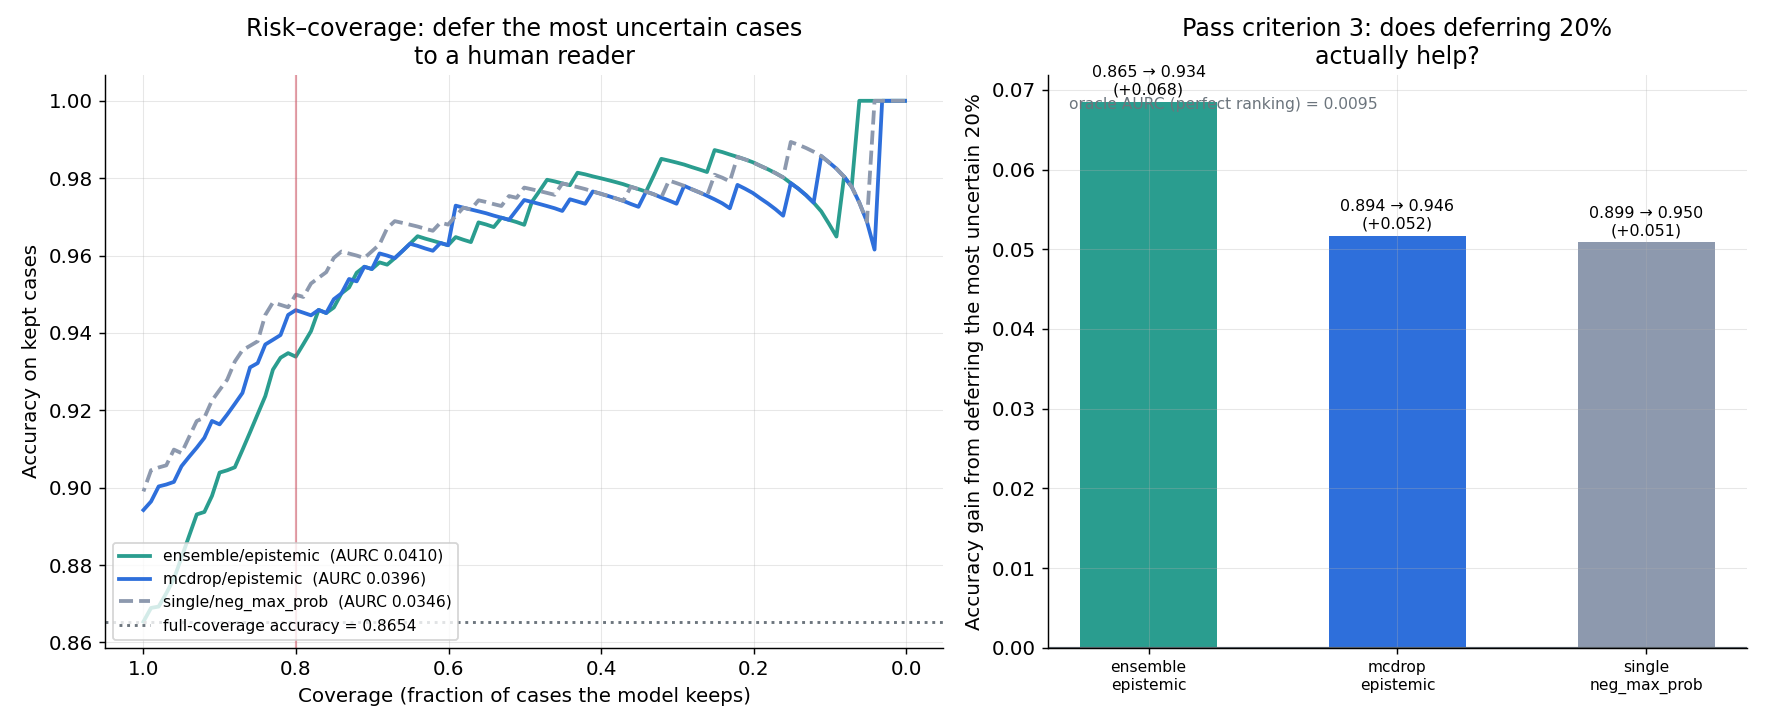

In [7]:
display(Image(os.path.join(FIG, '04_risk_coverage.png')))

### 一個值得注意的細節

比較同一個方法的不同分數會發現:**用 `epistemic` 排序病例,通常不如用
`total_entropy` 或 `1 − max_prob`。**

這與第 1 節的分解驗證完全一致:既然 OOD 與困難樣本的訊號大部分落在
aleatoric 而不是 epistemic,那麼要挑出「模型會答錯的病例」時,
包含 aleatoric 的總熵自然更有用。

**實務含意**:如果目標是「決定哪些病例轉人工」,直接用總熵或 max-prob 就好,
不需要付 MC Dropout 或 Ensemble 的代價。epistemic 的價值在於它回答
一個**不同**的問題(「這是不是我沒見過的資料類型」),而那個問題的答案
在本專案的實測中並不可靠。

## 4. 計算成本的取捨:T 與 M

兩者的成本結構完全不同:
- **T**(MC Dropout 前向次數)是**推論**成本,線性增加延遲,訓練一次即可。
- **M**(Ensemble 大小)是**訓練**成本(線性增加訓練時間與儲存),推論時也線性增加延遲。

在臨床部署上這兩種成本的可接受度差很多 —— 訓練是一次性的,推論延遲是每個病例都要付。

In [8]:
cb = pd.DataFrame(RES['cost_benefit']['rows'])
for kind in ['mcdrop','ensemble']:
    sub = cb[cb['kind']==kind].sort_values('budget')
    print(f'--- {kind} (OOD = {RES["cost_benefit"]["ood_set"]}) ---')
    display(sub[['budget','auroc_epistemic','auroc_total','in_epistemic_mean','accuracy']].round(4))

--- mcdrop (OOD = dermamnist[ood]) ---


,budget,auroc_epistemic,auroc_total,in_epistemic_mean,accuracy
0,1,NaN,0.7415,0.0000,0.8846
1,2,0.7143,0.7509,0.0108,0.8926
2,5,0.7587,0.7615,0.0174,0.8910
3,10,0.7698,0.7651,0.0199,0.8974
4,20,0.7823,0.7688,0.0206,0.8910
5,50,0.7885,0.7707,0.0209,0.8942
6,100,0.7907,0.7708,0.0209,0.8942


--- ensemble (OOD = dermamnist[ood]) ---


,budget,auroc_epistemic,auroc_total,in_epistemic_mean,accuracy
7,1,NaN,0.7710,0.0000,0.8990
8,2,0.7708,0.7974,0.0298,0.8670
9,3,0.8247,0.7984,0.0241,0.8702
10,4,0.8473,0.8136,0.0260,0.8830
11,5,0.8672,0.8295,0.0248,0.8654


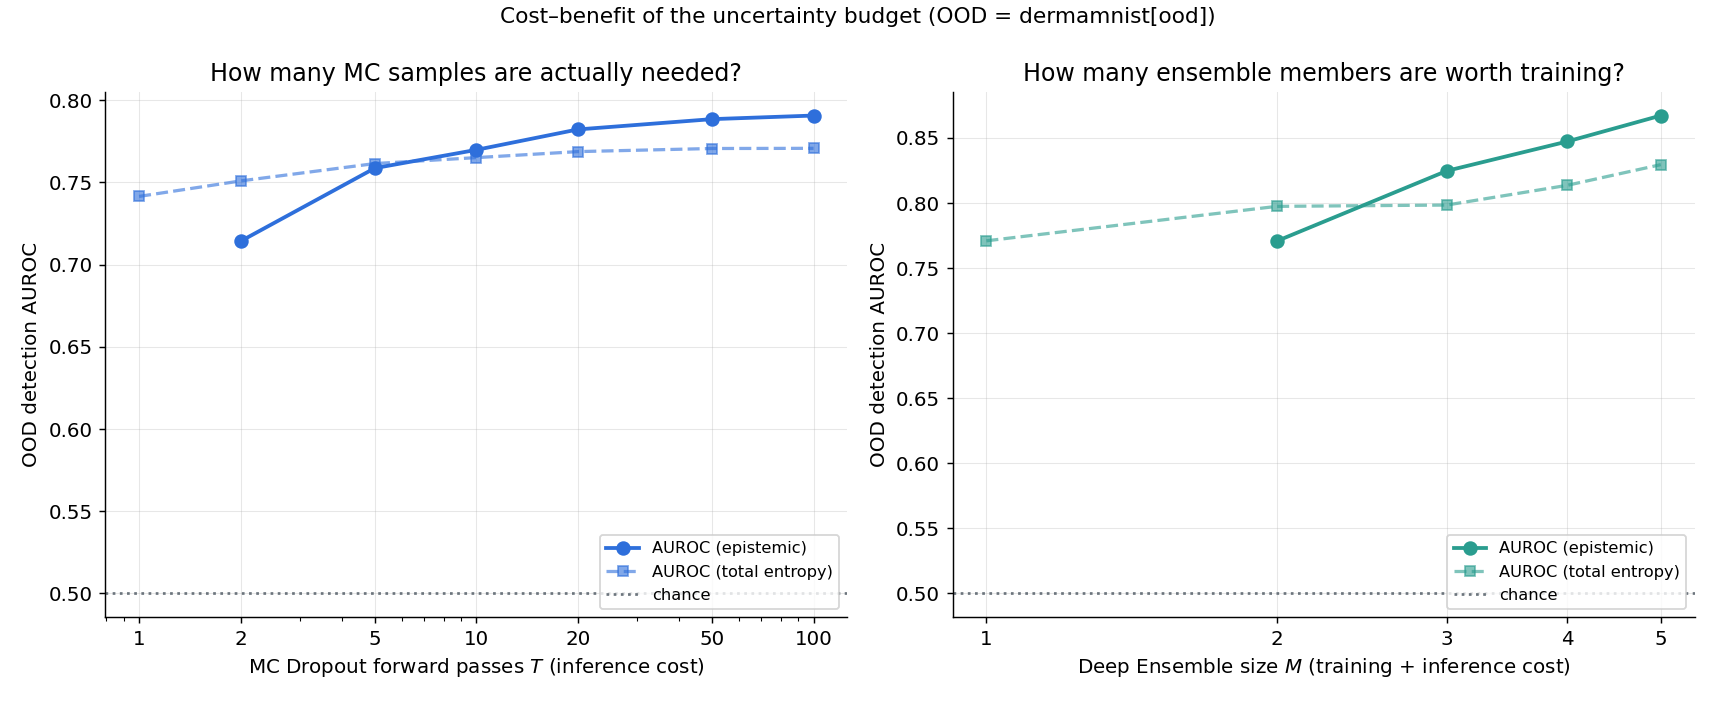

In [9]:
display(Image(os.path.join(FIG, '05_cost_benefit.png')))

## 小結與誠實面總表

| 通關標準 | 結果 |
|---|---|
| 1 · OOD 的 epistemic 直方圖明顯右移 | **部分成立** —— FashionMNIST 組反向 |
| 2 · 三組難度 AUROC 依序下降 | **被推翻** —— 「最簡單」的那組最難偵測 |
| 3 · 放棄 20% 最不確定樣本,準確率明顯提升 | **成立** |
| 4 · Deep Ensemble 通常優於 MC Dropout | 見第一本的配對 bootstrap |

三個與預期相反的發現,每一個都有機制解釋:

1. **模型對 FashionMNIST 比對胸片更自信** → ReLU 網路在遠離資料處任意自信
   (Hein et al. 2019)。「語意距離遠」不等於「容易偵測」。
2. **trivial 像素統計在多數組別打敗模型** → 常見 OOD benchmark 的成功
   大部分來自低階統計差異,而不是模型的語意理解。
3. **換分佈主要抬升 aleatoric 而非 epistemic** → 熵分解的語意標籤在深度學習中
   不可靠;這解釋了為何 epistemic 當 OOD 分數效果有限,也解釋了為何
   總熵在 risk–coverage 上反而更好用。

完整限制與誠實章節見 [`../README.md`](../README.md)。